In [1]:
import pandas as pd

path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\sft_qwen25_15b\kbg_sft_dataset_1.csv"
dataset = pd.read_csv(path)
# Check dataset
print(dataset.shape)
print(dataset.columns)
dataset.head()

(634, 15)
Index(['S.NO', 'file', 'index', 'consultation', 'Report', 'Factuality Score',
       'coverage', 'token_length', 'Cleaned_Report', 'FRE', 'FKGL', 'SMOG',
       'Dale_Chall', 'Cleaned_token_length', 'conciseness_score'],
      dtype='str')


,S.NO,file,index,consultation,Report,Factuality Score,coverage,token_length,Cleaned_Report,FRE,FKGL,SMOG,Dale_Chall,Cleaned_token_length,conciseness_score
0,1,C:\Users\Aman Kumar Singh\Desktop\coverage_par...,10,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,1.000,911,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,35.925689,16.929589,15.247665,12.398679,862,0.746781
1,2,C:\Users\Aman Kumar Singh\Desktop\coverage_par...,46,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,1.000,971,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,37.257509,14.493113,14.499530,12.498638,931,0.598712
2,3,C:\Users\Aman Kumar Singh\Desktop\coverage_par...,27,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,1.000,1106,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,32.742089,14.758912,15.355772,12.732271,1061,0.319742
3,4,C:\Users\Aman Kumar Singh\Desktop\coverage_par...,0,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.750,917,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,28.561296,17.818759,16.183972,13.122399,865,0.555258
4,5,C:\Users\Aman Kumar Singh\Desktop\coverage_par...,1,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.875,874,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,41.338523,15.377750,14.015710,12.202239,827,0.719152


In [2]:
import numpy as np

dataset_500 = dataset.head(500).copy()

dataset_500["quality_score"] = np.sqrt(
    dataset_500["Factuality Score"] * dataset_500["coverage"]
)

dataset_500[["Factuality Score", "coverage", "quality_score"]].head()

,Factuality Score,coverage,quality_score
0,1.0,1.000,1.000000
1,1.0,1.000,1.000000
2,1.0,1.000,1.000000
3,1.0,0.750,0.866025
4,1.0,0.875,0.935414


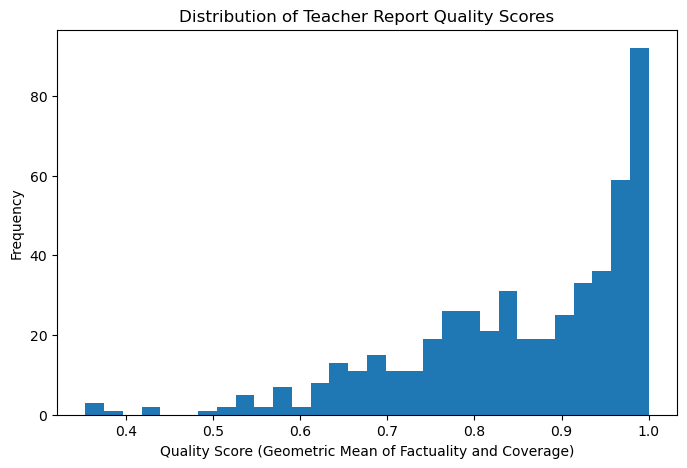

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataset_500["quality_score"], bins=30)

plt.xlabel("Quality Score (Geometric Mean of Factuality and Coverage)")
plt.ylabel("Frequency")
plt.title("Distribution of Teacher Report Quality Scores")

plt.show()